## Import mathematica CS data
The data is one matrix organized as 
$$
\begin{bmatrix}
\phi_1 & r_1 & Re(u(r_1)) & Im(u(r_1)) \\
\phi_1 & r_2 & Re(u(r_1)) & Im(u(r_1))\\
 & &\cdots & \\
\phi_2 & r_1 & Re(u(r_2)) & Im(u(r_2))\\
\phi_2 & r_2 & Re(u(r_2)) & Im(u(r_2))\\
& & \cdots&
\end{bmatrix}
$$

In [1]:
import pandas as pd 
from dvr import *

In [2]:
data = pd.read_csv("mathematica_CS_training_wavefunctions.csv", header=None)
data.columns = ['phi', 'r', 'u_re', 'u_im']

# collect all unique phi values in an array
phi_values = data['phi'].unique()

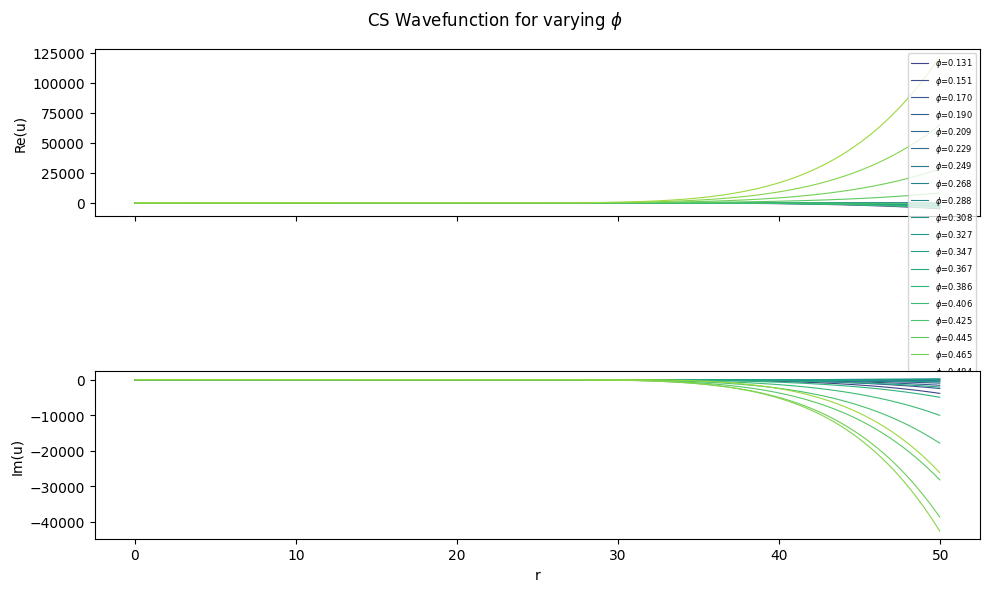

In [3]:
# plot all data
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 6))

colors = plt.cm.viridis(np.linspace(0.2, 0.85, len(phi_values)))

for i, phi in enumerate(phi_values):
    subset = data[data['phi'] == phi]
    rs = subset['r'].values
    u_re = subset['u_re'].values
    u_im = subset['u_im'].values

    ax1.plot(rs, u_re, color=colors[i], label=rf'$\phi$={phi:.3f}', linewidth=0.8)
    ax2.plot(rs, u_im, color=colors[i], linewidth=0.8)

ax1.set_ylabel('Re(u)')
ax2.set_ylabel('Im(u)')
ax2.set_xlabel('r')
ax1.legend(fontsize=6)
fig.suptitle(r"CS Wavefunction for varying $\phi$")
plt.tight_layout()
plt.show()

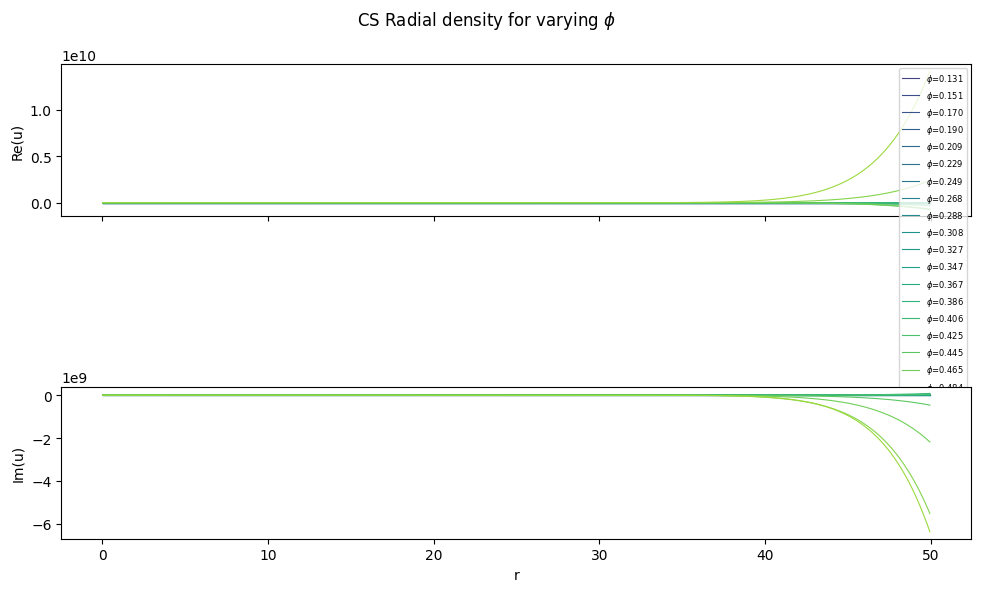

In [4]:
# plot radial density
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 6))

colors = plt.cm.viridis(np.linspace(0.2, 0.85, len(phi_values)))

for i, phi in enumerate(phi_values):
    subset = data[data['phi'] == phi]
    rs = subset['r'].values
    u_re = subset['u_re'].values
    u_im = subset['u_im'].values
    u = u_re + 1j*u_im

    rho = u**2

    ax1.plot(rs, np.real(rho), color=colors[i], label=rf'$\phi$={phi:.3f}', linewidth=0.8)
    ax2.plot(rs, np.imag(rho), color=colors[i], linewidth=0.8)

ax1.set_ylabel('Re(u)')
ax2.set_ylabel('Im(u)')
ax2.set_xlabel('r')
ax1.legend(fontsize=6)
fig.suptitle(r"CS Radial density for varying $\phi$")
plt.tight_layout()
plt.show()

## Train EC on these wavefunctions

First, convert wavefunction to DVR states for training data.

In [10]:
# set up DVR
n = 256
phi = pi / 24
real_res = 1.606 - 1j*0.047
L = 35

gauss_s = lambda r: 2.0 * exp(-((r-3.0)/1.5)**2) # potential

test_system = DVR(n, L, rotation_angle=phi, potential=gauss_s)

In [11]:
# convert mathematica data to DVR states
states = []

for i, phi in enumerate(phi_values):
    subset = data[data['phi'] == phi]
    rs = subset['r'].values
    u_re = subset['u_re'].values
    u_im = subset['u_im'].values

    wavefunc = u_re + 1j*u_im
    state = test_system.construct_dvrstate_from_wavefunc(rs, wavefunc)

    states.append(state)

states = np.array(states)

Train EC on these mathematica states

In [12]:
test_ecsystem = ECSystem(n, L, resonance_energy=real_res, potential=gauss_s)
test_ecsystem.train_from_outside_data(phi_values, states)
test_ecsystem.construct_basis()

Predict at $\phi=0.0$.

In [13]:
# grab energies and rr
phi_predict = 0.0
energies, rrs = test_ecsystem.predict(rotation_angles_predict=[phi_predict], rotate_rr=False)
print(f"Mathematica predicted energy: {energies}.\nMathematica predicted rr: {rrs}")

Mathematica predicted energy: [np.complex128(1.6251384353826082-0.04696164283575321j)].
Mathematica predicted rr: [np.complex128(0.1963164017746899+1.2874912532227285j)]


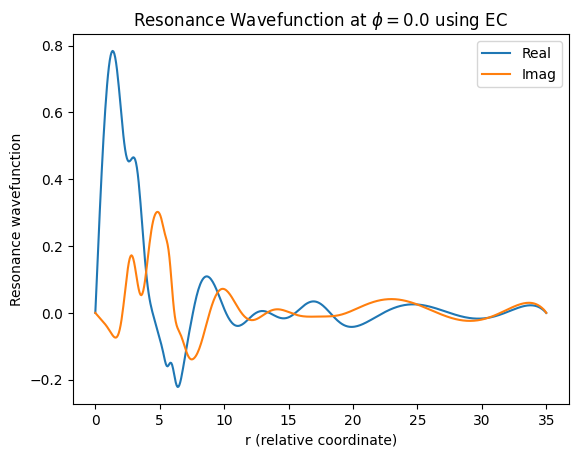

In [14]:
# plot wavefunction
x_plot = np.linspace(0.0, L, 500)
mathematica_trained_prediction = test_ecsystem.grab_wavefunc_from_prediction(phi_predict, x_plot)
fig, ax = plt.subplots()
ax.plot(x_plot, np.real(mathematica_trained_prediction), label='Real')
ax.plot(x_plot, np.imag(mathematica_trained_prediction), label='Imag')
ax.set_xlabel("r (relative coordinate)")
ax.set_ylabel("Resonance wavefunction")
ax.set_title(r"Resonance Wavefunction at $\phi=0.0$ using EC")
ax.legend()
plt.show()